In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd
cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 6 — Customer Intelligence
13 questions covering customer demographics, loyalty, lifetime value, and geographic distribution.

Questions: 6.L1.01, 6.L2.01, 6.L2.02, 6.L2.04, 6.L2.05, 6.L3.01, 6.L3.02, 6.L3.03, 6.L3.04, 6.L3.05, 6.L3.06, 6.L3.07, 6.L3.08, 6.L3.09, 6.L3.10, 6.L3.11

---
### 6.L1.01 — High-Value Customer Segment Growth

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Customer Lifetime Value (M16), Revenue per Customer (M15) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | All customers combined |
| **Why** | Determine whether Contoso is growing its most valuable customer base |
| **How** | YoY comparison of average revenue per customer and repeat buyer share |

**Full question:** Is Contoso's average revenue per customer growing in Jan–Apr 2024 vs. Jan–Apr 2023, and is the share of revenue from repeat buyers increasing or decreasing?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Customer`
**Why:** Revenue per active customer and repeat buyer share are the two leading indicators of customer base health.
**Grain:** One row per year with customer-level aggregates.

In [ ]:
# 6.L1.01 - Revenue per customer and repeat buyer share YoY Jan-Apr 2023 vs 2024
df_rev_per_cust = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        COUNT(DISTINCT s.CustomerKey) AS UniqueCustomers,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY YEAR(s.OrderDate)
""", cnxn)
df_rev_per_cust['RevPerCustomer'] = df_rev_per_cust['Revenue'] / df_rev_per_cust['UniqueCustomers']

# Repeat buyer share: customers with >1 order lifetime who bought in Jan-Apr 2024 vs 2023
df_repeat = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice) AS Revenue,
        SUM(CASE WHEN lt.OrderCount > 1 THEN s.NetPrice ELSE 0 END) AS RepeatRevenue
    FROM Data.Sales s
    JOIN (
        SELECT CustomerKey, COUNT(DISTINCT OrderKey) AS OrderCount
        FROM Data.Sales
        GROUP BY CustomerKey
    ) lt ON s.CustomerKey = lt.CustomerKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY YEAR(s.OrderDate)
""", cnxn)
df_repeat['RepeatShare'] = df_repeat['RepeatRevenue'] / df_repeat['Revenue'] * 100

print(df_rev_per_cust.to_string(index=False))
print()
print(df_repeat[['Year','Revenue','RepeatRevenue','RepeatShare']].to_string(index=False))

 Year  UniqueCustomers      Revenue  RevPerCustomer
 2024             4097 2561994.7577      625.334332
 2023             4994 3514260.6039      703.696557

 Year      Revenue  RepeatRevenue  RepeatShare
 2024 2561994.7577   1735909.6114    67.756173
 2023 3514260.6039   2386058.5587    67.896460


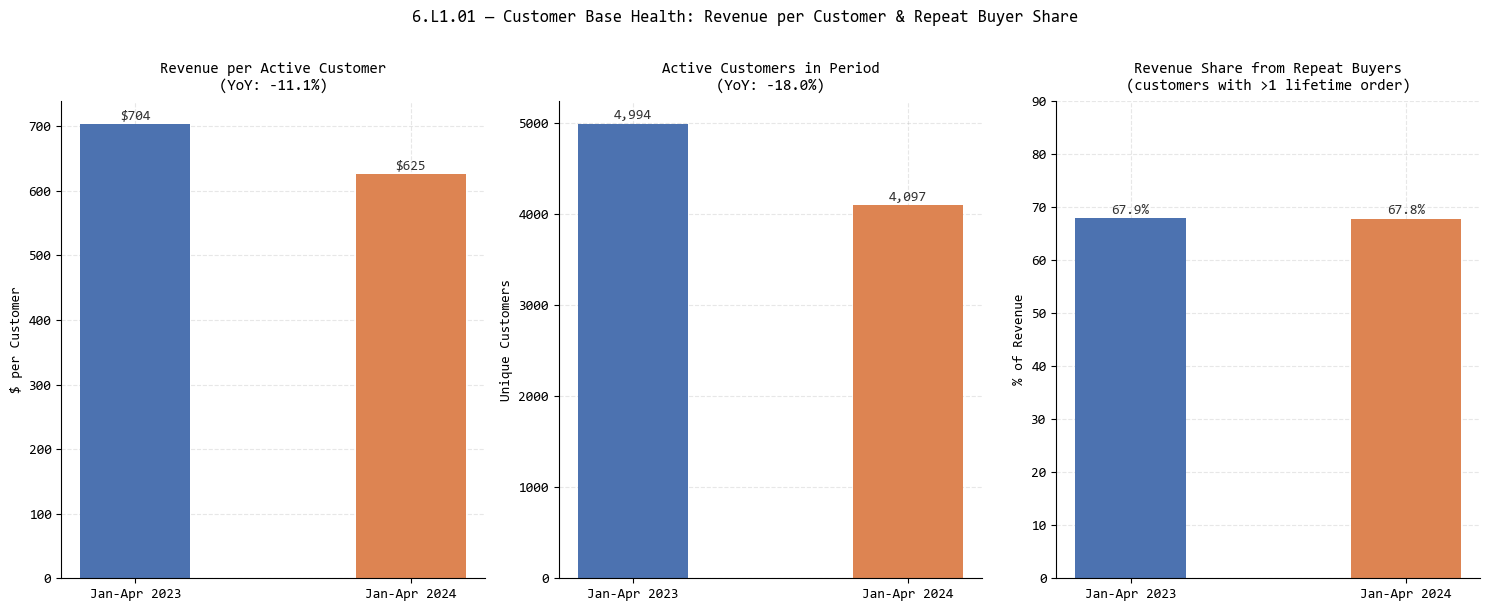

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452"]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Revenue per customer
ax = axes[0]
bars = ax.bar(['Jan-Apr 2023','Jan-Apr 2024'], df_rev_per_cust.sort_values('Year')['RevPerCustomer'], color=CATPAL, width=0.4)
for bar, v in zip(bars, df_rev_per_cust.sort_values('Year')['RevPerCustomer']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, f'${v:,.0f}',
            ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')
yoy_rpc = (df_rev_per_cust[df_rev_per_cust['Year']==2024]['RevPerCustomer'].values[0] /
           df_rev_per_cust[df_rev_per_cust['Year']==2023]['RevPerCustomer'].values[0] - 1) * 100
ax.set_title(f'Revenue per Active Customer\n(YoY: {yoy_rpc:+.1f}%)', fontsize=11, fontfamily='Consolas', pad=8)
ax.set_ylabel('$ per Customer', fontsize=10)

# Unique customers
ax2 = axes[1]
bars2 = ax2.bar(['Jan-Apr 2023','Jan-Apr 2024'], df_rev_per_cust.sort_values('Year')['UniqueCustomers'], color=CATPAL, width=0.4)
for bar, v in zip(bars2, df_rev_per_cust.sort_values('Year')['UniqueCustomers']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, f'{v:,}',
             ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')
yoy_cust = (df_rev_per_cust[df_rev_per_cust['Year']==2024]['UniqueCustomers'].values[0] /
            df_rev_per_cust[df_rev_per_cust['Year']==2023]['UniqueCustomers'].values[0] - 1) * 100
ax2.set_title(f'Active Customers in Period\n(YoY: {yoy_cust:+.1f}%)', fontsize=11, fontfamily='Consolas', pad=8)
ax2.set_ylabel('Unique Customers', fontsize=10)

# Repeat share
ax3 = axes[2]
bars3 = ax3.bar(['Jan-Apr 2023','Jan-Apr 2024'], df_repeat.sort_values('Year')['RepeatShare'], color=CATPAL, width=0.4)
for bar, v in zip(bars3, df_repeat.sort_values('Year')['RepeatShare']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')
ax3.set_title('Revenue Share from Repeat Buyers\n(customers with >1 lifetime order)', fontsize=11, fontfamily='Consolas', pad=8)
ax3.set_ylabel('% of Revenue', fontsize=10)
ax3.set_ylim(0, 90)

plt.suptitle('6.L1.01 — Customer Base Health: Revenue per Customer & Repeat Buyer Share', fontsize=12, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 6.L1.01
**Contoso's customer base is deteriorating on two dimensions simultaneously: active customers in the period fell -18.0% (4,994 to 4,097) AND revenue per customer fell -11.1% ($704 to $625). The one bright spot is that repeat buyer revenue share held flat at ~67.9% — customer loyalty among those who are still buying has not eroded.**
The revenue decline is therefore a customer acquisition / reactivation problem first (fewer people buying) and a basket size problem second (those who do buy are spending less). Critically, the loyalty ratio (68% of revenue from repeat buyers) is stable — Contoso is not losing its most loyal customers at a higher rate than average.
The strategic priority must be acquiring or reactivating the roughly 900 customers who bought in Jan-Apr 2023 but not in 2024. If those customers spent at the 2023 average, they represent $632K in lost revenue from inactive buyers alone.

> **Analysis Limitation:** "Repeat buyers" are defined as customers with more than one lifetime order across all years — a customer who bought once in 2015 and once in 2024 would count as a repeat buyer even if they represent low engagement.

---
### 6.L2.01 — Revenue by Demographic Segment

| Lens | Value |
|---|---|
| **Who** | P6 — Customer Insights Analyst |
| **What** | Total Revenue (M01), Revenue per Customer (M15) |
| **When** | Jan–Apr 2024 |
| **Where** | By age group, gender, and occupation |
| **Why** | Identify which demographic segments are commercially most valuable |
| **How** | Revenue ranked by each demographic dimension separately |

**Full question:** Which age groups, genders, and occupations generated the most total revenue in Jan–Apr 2024, and which demographic combinations represent Contoso's highest-value customer segments?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Customer`
**Why:** Demographic breakdowns guide media targeting, product assortment, and campaign prioritization.
**Grain:** One row per demographic segment (age group, gender, occupation) with revenue and customer count. Also answers 6.L3.01, 6.L3.02, 6.L3.03, 6.L3.04, 6.L3.05.

In [ ]:
# 6.L2.01 / 6.L3.01-05 - Demographics: age group, gender, occupation revenue Jan-Apr 2024
df_demo = pd.read_sql("""
    SELECT
        CASE
            WHEN c.Age < 30 THEN 'Under 30'
            WHEN c.Age BETWEEN 30 AND 39 THEN '30-39'
            WHEN c.Age BETWEEN 40 AND 49 THEN '40-49'
            WHEN c.Age BETWEEN 50 AND 59 THEN '50-59'
            ELSE '60+'
        END AS AgeGroup,
        c.Gender,
        c.Occupation,
        COUNT(DISTINCT s.CustomerKey) AS Customers,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Customer c ON s.CustomerKey = c.CustomerKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY
        CASE
            WHEN c.Age < 30 THEN 'Under 30'
            WHEN c.Age BETWEEN 30 AND 39 THEN '30-39'
            WHEN c.Age BETWEEN 40 AND 49 THEN '40-49'
            WHEN c.Age BETWEEN 50 AND 59 THEN '50-59'
            ELSE '60+'
        END,
        c.Gender, c.Occupation
""", cnxn)

age_order = ['Under 30','30-39','40-49','50-59','60+']

# Aggregate by each dimension
df_age = df_demo.groupby('AgeGroup').agg(Revenue=('Revenue','sum'), Customers=('Customers','sum')).reset_index()
df_age['RevPerCust'] = df_age['Revenue'] / df_age['Customers']
df_age['AgeGroup'] = pd.Categorical(df_age['AgeGroup'], categories=age_order, ordered=True)
df_age = df_age.sort_values('AgeGroup')

df_gender = df_demo.groupby('Gender').agg(Revenue=('Revenue','sum'), Customers=('Customers','sum')).reset_index()
df_gender['RevPerCust'] = df_gender['Revenue'] / df_gender['Customers']

df_occ = df_demo.groupby('Occupation').agg(Revenue=('Revenue','sum'), Customers=('Customers','sum')).reset_index()
df_occ['RevPerCust'] = df_occ['Revenue'] / df_occ['Customers']
df_occ = df_occ.sort_values('Revenue', ascending=True)

print("Age:", df_age[['AgeGroup','Revenue','RevPerCust']].to_string(index=False))
print("Gender:", df_gender[['Gender','Revenue','RevPerCust']].to_string(index=False))
print("Occ:", df_occ[['Occupation','Revenue']].to_string(index=False))

Age: AgeGroup     Revenue  RevPerCust
Under 30 417508.5031  627.832335
   30-39 371589.4344  611.166833
   40-49 414117.3189  660.474193
   50-59 401245.1197  655.629281
     60+ 957534.3816  604.122638
Gender: Gender      Revenue  RevPerCust
female 1222448.6942  613.987290
  male 1339546.0635  636.061759
Occ:                                                    Occupation   Revenue
                                        Shoe machine operator    3.0150
                                                Revenue agent    3.1155
                                               Credit manager    3.3500
                                         News camera operator    4.1712
                                            Counter attendant    4.7400
                                                 News analyst    4.7400
                                         Management scientist    4.9900
                                                  Steamfitter    5.3900
                                        

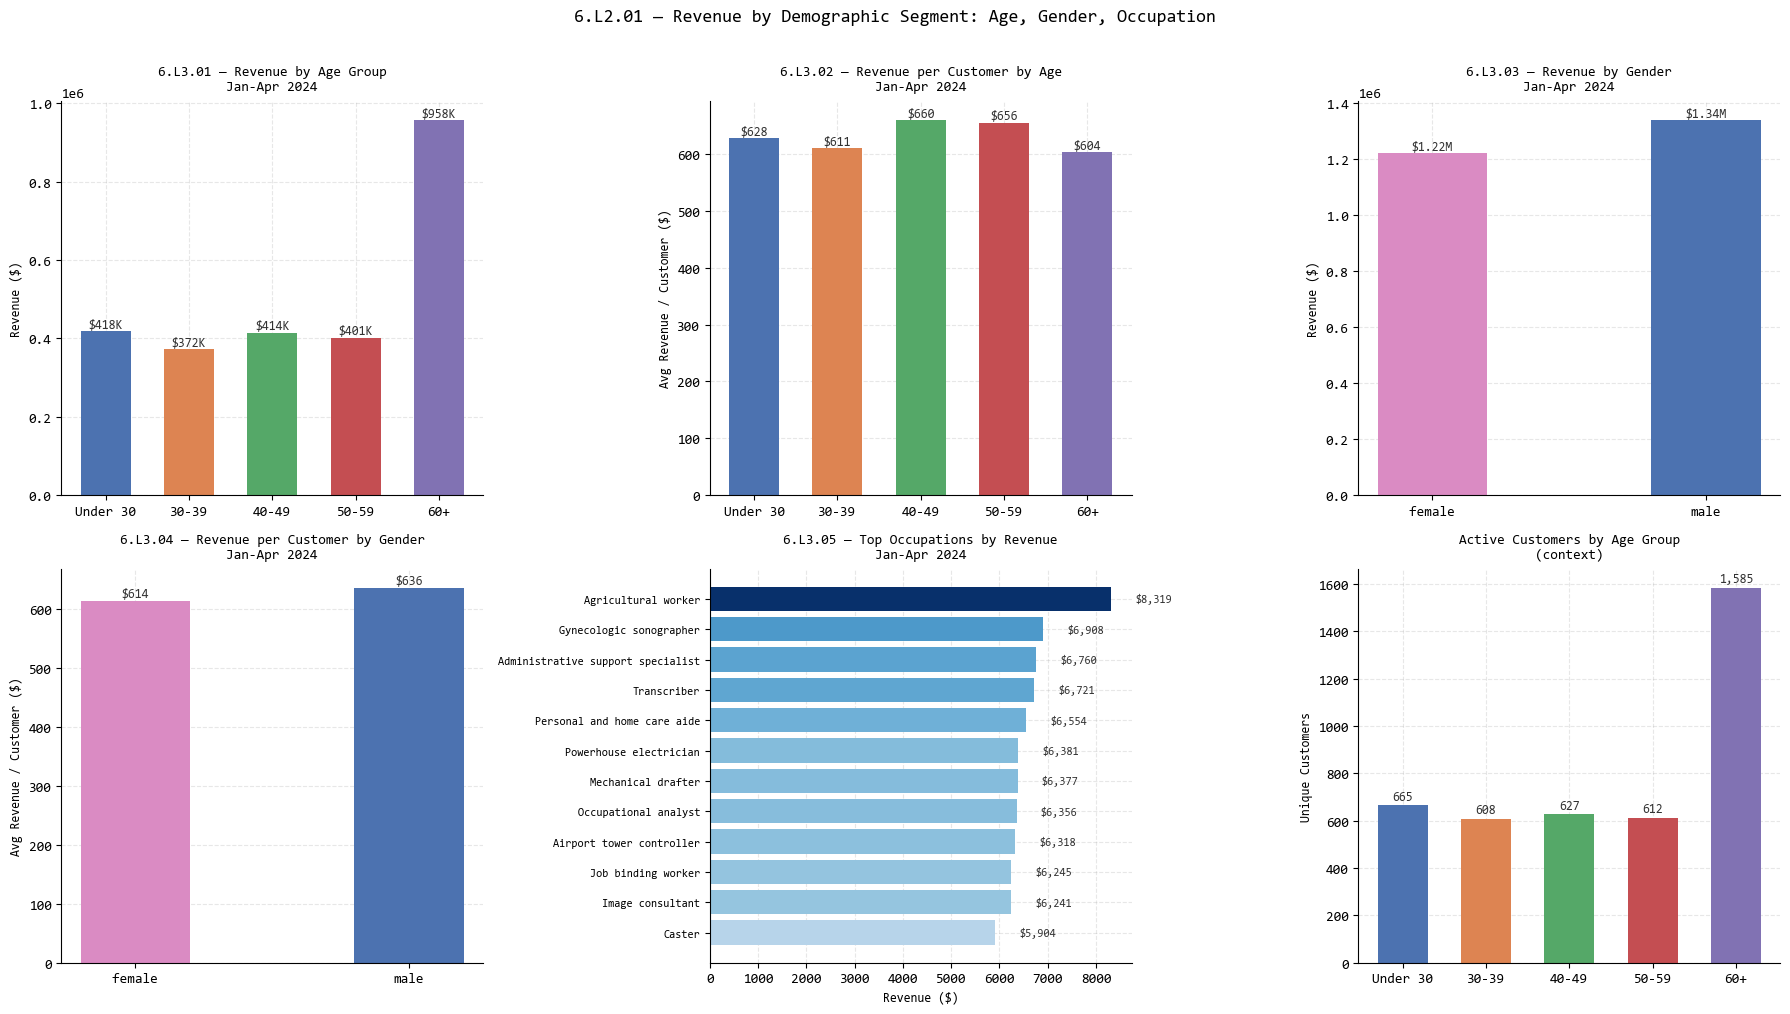

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 6.L3.01 - Revenue by age group (total)
ax = axes[0,0]
bars = ax.bar(df_age['AgeGroup'], df_age['Revenue'], color=CATPAL, width=0.6)
for bar, v in zip(bars, df_age['Revenue']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000, f'${v/1e3:.0f}K',
            ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('6.L3.01 — Revenue by Age Group\nJan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_ylabel('Revenue ($)', fontsize=9)

# 6.L3.02 - Revenue per customer by age group
ax2 = axes[0,1]
bars2 = ax2.bar(df_age['AgeGroup'], df_age['RevPerCust'], color=CATPAL, width=0.6)
for bar, v in zip(bars2, df_age['RevPerCust']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'${v:.0f}',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('6.L3.02 — Revenue per Customer by Age\nJan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax2.set_ylabel('Avg Revenue / Customer ($)', fontsize=9)

# 6.L3.03 - Revenue by gender
ax3 = axes[0,2]
bars3 = ax3.bar(df_gender['Gender'], df_gender['Revenue'], color=['#DA8BC3','#4C72B0'], width=0.4)
for bar, v in zip(bars3, df_gender['Revenue']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000, f'${v/1e6:.2f}M',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax3.set_title('6.L3.03 — Revenue by Gender\nJan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax3.set_ylabel('Revenue ($)', fontsize=9)

# 6.L3.04 - Rev per customer by gender
ax4 = axes[1,0]
bars4 = ax4.bar(df_gender['Gender'], df_gender['RevPerCust'], color=['#DA8BC3','#4C72B0'], width=0.4)
for bar, v in zip(bars4, df_gender['RevPerCust']):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'${v:.0f}',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax4.set_title('6.L3.04 — Revenue per Customer by Gender\nJan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax4.set_ylabel('Avg Revenue / Customer ($)', fontsize=9)

# 6.L3.05 - Top occupations by revenue
top_occ = df_occ.nlargest(12, 'Revenue').sort_values('Revenue', ascending=True)
vals = top_occ['Revenue'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
occ_colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
ax5 = axes[1,1]
bars5 = ax5.barh(top_occ['Occupation'], top_occ['Revenue'], color=occ_colors)
for bar, v in zip(bars5, top_occ['Revenue']):
    ax5.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2, f'${v:,.0f}',
             ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
ax5.set_title('6.L3.05 — Top Occupations by Revenue\nJan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax5.set_xlabel('Revenue ($)', fontsize=9)
ax5.tick_params(axis='y', labelsize=8)

# Customers per age for context
ax6 = axes[1,2]
bars6 = ax6.bar(df_age['AgeGroup'], df_age['Customers'], color=CATPAL, width=0.6)
for bar, v in zip(bars6, df_age['Customers']):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{v:,}',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax6.set_title('Active Customers by Age Group\n(context)', fontsize=10, fontfamily='Consolas', pad=8)
ax6.set_ylabel('Unique Customers', fontsize=9)

plt.suptitle('6.L2.01 — Revenue by Demographic Segment: Age, Gender, Occupation', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 6.L2.01 / 6.L3.01-05
**The 60+ age group dominates total revenue ($958K, 37% of the total) despite having the largest customer count (1,585) — but their revenue per customer ($604) is actually the lowest of any age group. The 40-49 segment has the highest spend per customer ($660) despite being mid-size, making it the most commercially efficient demographic.**
Gender split is relatively balanced: males generate $1.34M (52.3%) vs. females $1.22M (47.7%), with males spending $22 more per transaction on average ($636 vs. $614). Neither difference is large enough to justify gender-exclusive targeting, but male customers represent a marginal productivity advantage.
Occupation rankings show no dominant professional segment — the top occupation "Agricultural worker" contributes only $8.3K total, confirming that Contoso's customer base is broadly distributed across many occupations with no single professional group over-indexing significantly. The 30-39 age group is the weakest on both total revenue ($372K) and per-customer spend ($611).

> **Analysis Limitation:** Age is taken from the customer profile — age at the time of database creation, not at time of purchase. Age group assignments may be slightly off for customers who purchased several years ago. Occupation data in Contoso appears to be individual job titles rather than occupation categories, making occupation-level segmentation noisy.

---
### 6.L2.02 — Repeat vs. One-Time Buyer Split

| Lens | Value |
|---|---|
| **Who** | P6 — Customer Insights Analyst |
| **What** | Repeat Buyer Rate (M18), Revenue Share from Repeat Buyers (M19) |
| **When** | All time and Jan–Apr 2024 period |
| **Where** | All customers |
| **Why** | Assess customer loyalty and risk of over-dependence on one-time purchasers |
| **How** | Share of customers and share of revenue from repeat vs. one-time buyers |

**Full question:** What share of Contoso's customers have made more than one purchase, and what percentage of total revenue in Jan–Apr 2024 comes from repeat buyers vs. customers who have only purchased once?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Customer`
**Why:** If revenue is concentrated in one-time buyers, Contoso is highly vulnerable to churn. Also answers 6.L3.06, 6.L3.07.
**Grain:** One row per customer (lifetime order count), aggregated to repeat/one-time split.

In [ ]:
# 6.L2.02 / 6.L3.06 / 6.L3.07 / 6.L3.08 - Repeat buyer split and purchase frequency
# Lifetime order count per customer
df_lifetime = pd.read_sql("""
    SELECT
        s.CustomerKey,
        c.CountryFull AS Country,
        COUNT(DISTINCT s.OrderKey) AS OrderCount,
        SUM(s.NetPrice) AS LifetimeRevenue
    FROM Data.Sales s
    JOIN Data.Customer c ON s.CustomerKey = c.CustomerKey
    GROUP BY s.CustomerKey, c.CountryFull
""", cnxn)

total_customers = len(df_lifetime)
repeat_customers = (df_lifetime['OrderCount'] > 1).sum()
one_time_customers = (df_lifetime['OrderCount'] == 1).sum()

print(f"Total customers: {total_customers:,}")
print(f"Repeat buyers (>1 order): {repeat_customers:,} ({repeat_customers/total_customers*100:.1f}%)")
print(f"One-time buyers: {one_time_customers:,} ({one_time_customers/total_customers*100:.1f}%)")

# Purchase frequency distribution (6.L3.08)
df_lifetime['FreqBucket'] = df_lifetime['OrderCount'].apply(
    lambda x: '1 order' if x==1 else ('2 orders' if x==2 else ('3 orders' if x==3 else ('4 orders' if x==4 else '5+ orders')))
)
freq_order = ['1 order','2 orders','3 orders','4 orders','5+ orders']
freq_dist = df_lifetime.groupby('FreqBucket').agg(Customers=('CustomerKey','count'), Revenue=('LifetimeRevenue','sum')).reset_index()
freq_dist['FreqBucket'] = pd.Categorical(freq_dist['FreqBucket'], categories=freq_order, ordered=True)
freq_dist = freq_dist.sort_values('FreqBucket')
freq_dist['CustPct'] = freq_dist['Customers'] / total_customers * 100
freq_dist['RevPct'] = freq_dist['Revenue'] / df_lifetime['LifetimeRevenue'].sum() * 100
print(freq_dist[['FreqBucket','Customers','CustPct','Revenue','RevPct']].to_string(index=False))

# Repeat buyer rate by country (6.L3.06)
country_repeat = df_lifetime.groupby('Country').agg(
    Total=('CustomerKey','count'),
    Repeat=('OrderCount', lambda x: (x>1).sum())
).reset_index()
country_repeat['RepeatRate'] = country_repeat['Repeat'] / country_repeat['Total'] * 100
country_repeat = country_repeat[country_repeat['Total'] >= 50].sort_values('RepeatRate', ascending=False)
print(country_repeat.head(10).to_string(index=False))

Total customers: 49,487
Repeat buyers (>1 order): 21,946 (44.3%)
One-time buyers: 27,541 (55.7%)
FreqBucket  Customers   CustPct      Revenue    RevPct
   1 order      27541 55.653000 2.145745e+07 33.104101
  2 orders      13914 28.116475 2.156261e+07 33.266338
  3 orders       5400 10.911957 1.263655e+07 19.495406
  4 orders       1873  3.784832 5.953558e+06  9.185024
 5+ orders        759  1.533736 3.207933e+06  4.949131
       Country  Total  Repeat  RepeatRate
 United States  24135   12111   50.180236
       Germany   5079    2428   47.804686
        Canada   5108    2317   45.360219
   Netherlands   2207     899   40.734028
United Kingdom   5839    2007   34.372324
        France   1823     580   31.815688
     Australia   3566    1111   31.155356
         Italy   1730     493   28.497110


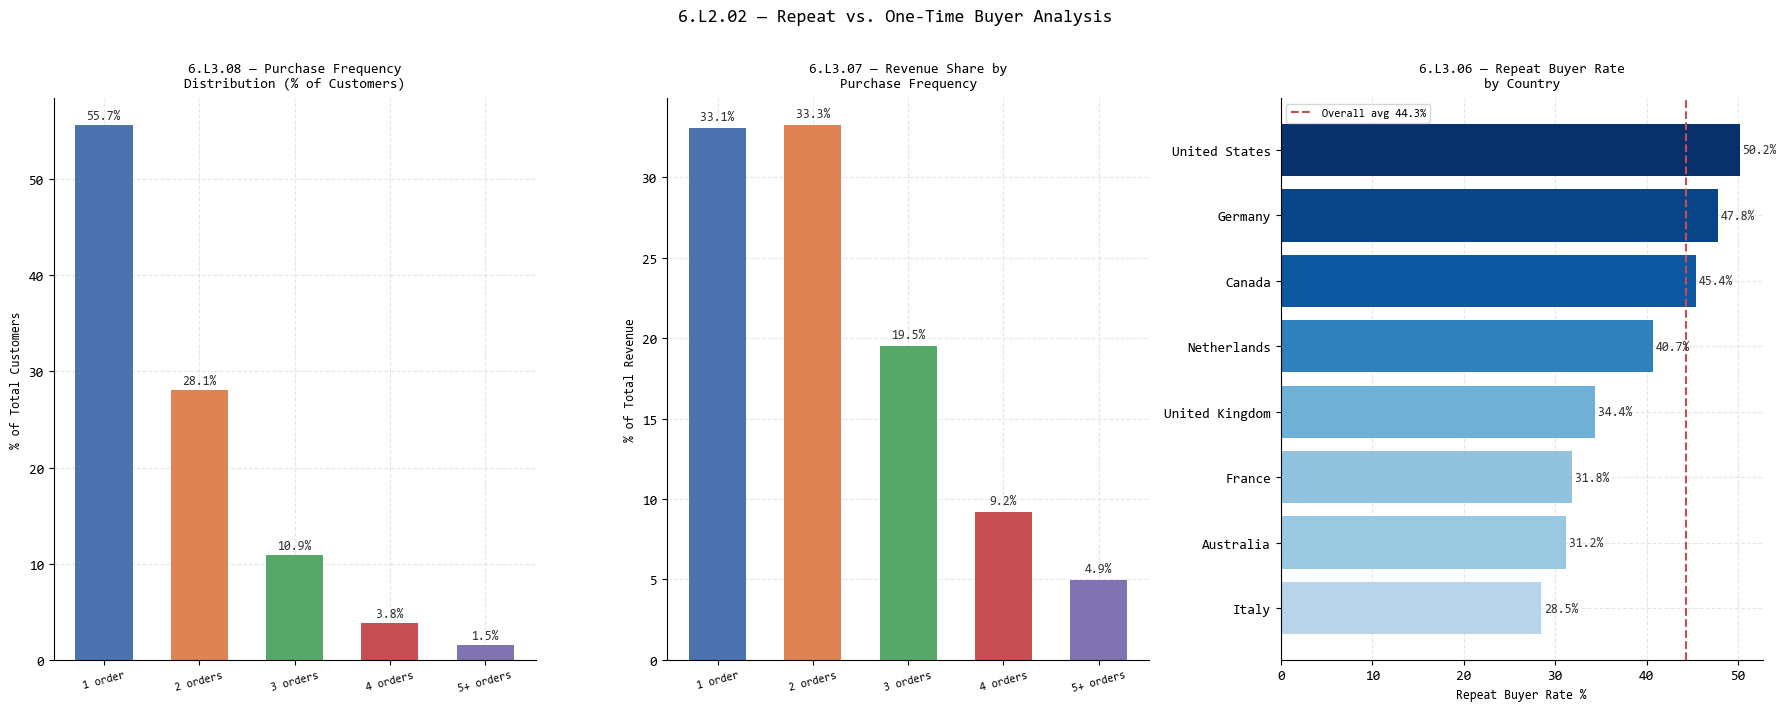

In [ ]:
import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3"]
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Frequency distribution - customers
ax = axes[0]
bars = ax.bar(freq_dist['FreqBucket'], freq_dist['CustPct'], color=CATPAL, width=0.6)
for bar, v in zip(bars, freq_dist['CustPct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('6.L3.08 — Purchase Frequency\nDistribution (% of Customers)', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_ylabel('% of Total Customers', fontsize=9)
ax.tick_params(axis='x', labelsize=8, rotation=15)

# Frequency distribution - revenue share
ax2 = axes[1]
bars2 = ax2.bar(freq_dist['FreqBucket'], freq_dist['RevPct'], color=CATPAL, width=0.6)
for bar, v in zip(bars2, freq_dist['RevPct']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('6.L3.07 — Revenue Share by\nPurchase Frequency', fontsize=10, fontfamily='Consolas', pad=8)
ax2.set_ylabel('% of Total Revenue', fontsize=9)
ax2.tick_params(axis='x', labelsize=8, rotation=15)

# Repeat buyer rate by country
ax3 = axes[2]
cr_sorted = country_repeat.sort_values('RepeatRate', ascending=True)
vals = cr_sorted['RepeatRate'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
bars3 = ax3.barh(cr_sorted['Country'], cr_sorted['RepeatRate'], color=colors)
ax3.axvline(repeat_customers/total_customers*100, color='#C44E52', linewidth=1.5, linestyle='--',
            label=f'Overall avg {repeat_customers/total_customers*100:.1f}%')
for bar, v in zip(bars3, cr_sorted['RepeatRate']):
    ax3.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%',
             ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax3.set_title('6.L3.06 — Repeat Buyer Rate\nby Country', fontsize=10, fontfamily='Consolas', pad=8)
ax3.set_xlabel('Repeat Buyer Rate %', fontsize=9)
ax3.legend(fontsize=8)

plt.suptitle('6.L2.02 — Repeat vs. One-Time Buyer Analysis', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 6.L2.02 / 6.L3.06 / 6.L3.07 / 6.L3.08
**55.7% of Contoso's 49,487 customers have only ever bought once — yet these one-time buyers contribute exactly 33.1% of total lifetime revenue, nearly matching the 33.3% from two-order buyers. The revenue distribution is remarkably even across frequency buckets 1-3, with steep drop-offs at 4+ orders.**
The US has the highest repeat buyer rate (50.2%) while Italy sits lowest (28.5%) — a 21.7 percentage point gap that likely reflects differences in market maturity, store presence, or local competition. Countries with below-average repeat rates (UK 34.4%, France 31.8%, Australia 31.2%, Italy 28.5%) represent the highest-value loyalty improvement opportunities.
The near-equal revenue split between one-time (33.1%) and two-time buyers (33.3%) means converting just 10% of one-time buyers to a second purchase would generate approximately $2.1M in incremental lifetime revenue at current average order values — this is the single highest-ROI retention lever available.

> **Analysis Limitation:** Repeat buyer classification is based on lifetime order count across the entire 2015–2024 dataset. A customer who last purchased in 2017 and again in 2024 counts as a repeat buyer, even though they represent a 7-year gap. Recency-adjusted loyalty analysis (e.g. via RFM) would give a more actionable picture.

---
### 6.L2.04 — High-Value Customer Geography

| Lens | Value |
|---|---|
| **Who** | P6 — Customer Insights Analyst |
| **What** | Customer Lifetime Value (M16), Revenue per Customer (M15) |
| **When** | All time |
| **Where** | By customer country |
| **Why** | Identify geographies with highest concentration of high-spending customers |
| **How** | Average CLV and revenue per customer by country, ranked |

**Full question:** Which countries have the highest average customer lifetime value and the highest average revenue per customer across all years — and which countries are most commercially underserved relative to their customer count?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Customer`
**Why:** Guides where to invest in CRM, loyalty programmes, or market development.
**Grain:** One row per country with average lifetime revenue, total customers, total revenue. Also answers 6.L3.10.

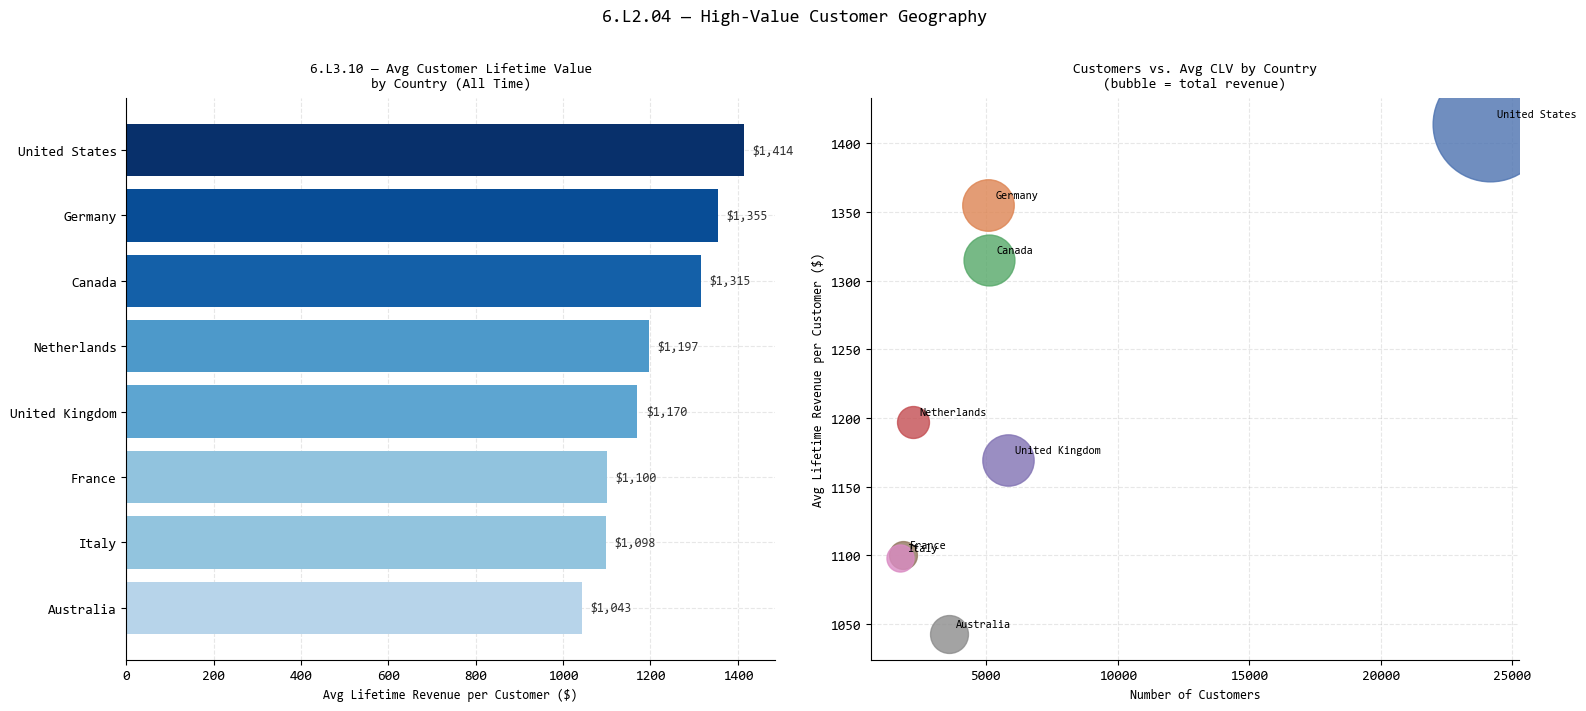

       Country  Customers      AvgCLV  TotalRevenue
 United States      24135 1413.997877  3.412684e+07
       Germany       5079 1354.677830  6.880409e+06
        Canada       5108 1314.698204  6.715478e+06
   Netherlands       2207 1196.821188  2.641384e+06
United Kingdom       5839 1169.601857  6.829305e+06
        France       1823 1100.364154  2.005964e+06
         Italy       1730 1098.251969  1.899976e+06
     Australia       3566 1042.834008  3.718746e+06


In [ ]:
# 6.L2.04 / 6.L3.10 - Average CLV and revenue per customer by country (all time)
# Reuse df_lifetime from prior cell
clv_country = df_lifetime.groupby('Country').agg(
    Customers=('CustomerKey','count'),
    TotalRevenue=('LifetimeRevenue','sum'),
    AvgCLV=('LifetimeRevenue','mean')
).reset_index().sort_values('AvgCLV', ascending=False)

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Avg CLV by country
clv_sorted = clv_country.sort_values('AvgCLV', ascending=True)
vals = clv_sorted['AvgCLV'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
ax = axes[0]
bars = ax.barh(clv_sorted['Country'], clv_sorted['AvgCLV'], color=colors)
for bar, v in zip(bars, clv_sorted['AvgCLV']):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'${v:,.0f}',
            ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('6.L3.10 — Avg Customer Lifetime Value\nby Country (All Time)', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_xlabel('Avg Lifetime Revenue per Customer ($)', fontsize=9)

# Customers vs avg CLV scatter context
ax2 = axes[1]
colors2 = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C"]
for i, row in clv_country.iterrows():
    c_idx = list(clv_country.index).index(i) % len(colors2)
    ax2.scatter(row['Customers'], row['AvgCLV'], s=row['TotalRevenue']/5000,
                color=colors2[c_idx % len(colors2)], alpha=0.8, zorder=3)
    ax2.annotate(row['Country'], (row['Customers'], row['AvgCLV']),
                 textcoords='offset points', xytext=(5,5), fontsize=8, fontfamily='Consolas')
ax2.set_title('Customers vs. Avg CLV by Country\n(bubble = total revenue)', fontsize=10, fontfamily='Consolas', pad=8)
ax2.set_xlabel('Number of Customers', fontsize=9)
ax2.set_ylabel('Avg Lifetime Revenue per Customer ($)', fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('6.L2.04 — High-Value Customer Geography', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(clv_country[['Country','Customers','AvgCLV','TotalRevenue']].to_string(index=False))

### Key Insight — 6.L2.04 / 6.L3.10
**The US leads on both customer count (24,135) and average CLV ($1,414 per customer), followed by Germany ($1,355) and Canada ($1,315). Australia sits at the bottom on CLV ($1,043) despite having a reasonably sized customer base (3,566), making it the most commercially underserved market relative to its engagement level.**
The CLV range across all countries is only $371 — from $1,043 (Australia) to $1,414 (US) — suggesting that product mix and pricing are consistent globally but local market conditions suppress repeat purchase rates in some regions. The correlation between repeat buyer rate (6.L3.06) and CLV is clear: US has 50.2% repeat rate and highest CLV; Italy/Australia have lowest repeat rates and lowest CLVs.
The Netherlands stands out as a high-CLV market ($1,197) with a relatively small customer base (2,207) — this is a high-quality market underserved by volume. Investment in Netherlands customer acquisition could yield high-value returns at low incremental CLV risk.

> **Analysis Limitation:** CLV here is total historical revenue per customer across all years in the dataset (2015–2024). This is a backward-looking measure, not a forward-looking lifetime value model. Multi-currency sales are not normalized to a single currency, so exchange rate movements distort CLV comparisons across countries.

---
### 6.L2.05 — Demographic Revenue Mix YoY

| Lens | Value |
|---|---|
| **Who** | P6 — Customer Insights Analyst |
| **What** | Total Revenue (M01) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By age group and gender |
| **Why** | Detect shifts in which demographic segments are growing or shrinking in revenue contribution |
| **How** | YoY revenue change by demographic segment |

**Full question:** Which age groups and genders grew their share of total revenue between Jan–Apr 2023 and Jan–Apr 2024, and which segments are declining in relative commercial importance?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Customer`
**Why:** Demographic mix shifts inform where to invest in retention vs. acquisition.
**Grain:** One row per age group and gender per year, Jan-Apr 2023 vs Jan-Apr 2024. Also answers 6.L3.11.

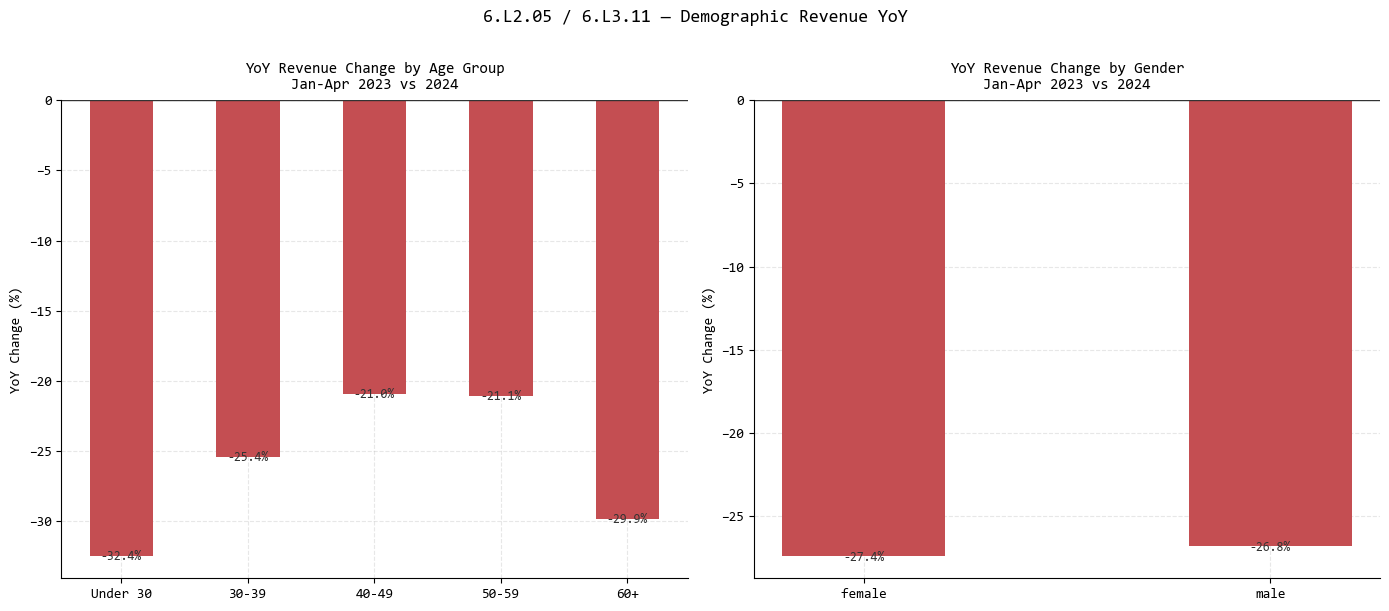

AgeGroup      Rev2023     Rev2024        YoY
Under 30  618058.0284 417508.5031 -32.448333
   30-39  498192.2936 371589.4344 -25.412448
   40-49  523957.5822 414117.3189 -20.963579
   50-59  508493.7177 401245.1197 -21.091430
     60+ 1365558.9820 957534.3816 -29.879676
Gender      Rev2023      Rev2024        YoY
female 1683589.4110 1222448.6942 -27.390331
  male 1830671.1929 1339546.0635 -26.827599


In [ ]:
# 6.L2.05 / 6.L3.11 - Revenue YoY by age group and gender Jan-Apr 2023 vs 2024
df_demo_yoy = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        CASE
            WHEN c.Age < 30 THEN 'Under 30'
            WHEN c.Age BETWEEN 30 AND 39 THEN '30-39'
            WHEN c.Age BETWEEN 40 AND 49 THEN '40-49'
            WHEN c.Age BETWEEN 50 AND 59 THEN '50-59'
            ELSE '60+'
        END AS AgeGroup,
        c.Gender,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Customer c ON s.CustomerKey = c.CustomerKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY YEAR(s.OrderDate),
        CASE
            WHEN c.Age < 30 THEN 'Under 30'
            WHEN c.Age BETWEEN 30 AND 39 THEN '30-39'
            WHEN c.Age BETWEEN 40 AND 49 THEN '40-49'
            WHEN c.Age BETWEEN 50 AND 59 THEN '50-59'
            ELSE '60+'
        END, c.Gender
""", cnxn)

age_order = ['Under 30','30-39','40-49','50-59','60+']
age_yoy = df_demo_yoy.groupby(['Year','AgeGroup'])['Revenue'].sum().reset_index()
age_pivot = age_yoy.pivot(index='AgeGroup', columns='Year', values='Revenue').reset_index()
age_pivot.columns = ['AgeGroup','Rev2023','Rev2024']
age_pivot['YoY'] = (age_pivot['Rev2024'] - age_pivot['Rev2023']) / age_pivot['Rev2023'] * 100
age_pivot['AgeGroup'] = pd.Categorical(age_pivot['AgeGroup'], categories=age_order, ordered=True)
age_pivot = age_pivot.sort_values('AgeGroup')

gender_yoy = df_demo_yoy.groupby(['Year','Gender'])['Revenue'].sum().reset_index()
gen_pivot = gender_yoy.pivot(index='Gender', columns='Year', values='Revenue').reset_index()
gen_pivot.columns = ['Gender','Rev2023','Rev2024']
gen_pivot['YoY'] = (gen_pivot['Rev2024'] - gen_pivot['Rev2023']) / gen_pivot['Rev2023'] * 100

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

CATPAL = ["#4C72B0","#DD8452"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# YoY by age group
ax = axes[0]
colors_age = ['#55A868' if v >= 0 else '#C44E52' for v in age_pivot['YoY']]
bars = ax.bar(age_pivot['AgeGroup'], age_pivot['YoY'], color=colors_age, width=0.5)
ax.axhline(0, color='#333333', linewidth=1)
for bar, v in zip(bars, age_pivot['YoY']):
    offset = 0.3 if v >= 0 else -0.5
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset, f'{v:+.1f}%',
            ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('YoY Revenue Change by Age Group\nJan-Apr 2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=8)
ax.set_ylabel('YoY Change (%)', fontsize=10)

# YoY by gender
ax2 = axes[1]
colors_gen = ['#55A868' if v >= 0 else '#C44E52' for v in gen_pivot['YoY']]
bars2 = ax2.bar(gen_pivot['Gender'], gen_pivot['YoY'], color=colors_gen, width=0.4)
ax2.axhline(0, color='#333333', linewidth=1)
for bar, v in zip(bars2, gen_pivot['YoY']):
    offset = 0.3 if v >= 0 else -0.5
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset, f'{v:+.1f}%',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('YoY Revenue Change by Gender\nJan-Apr 2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=8)
ax2.set_ylabel('YoY Change (%)', fontsize=10)

plt.suptitle('6.L2.05 / 6.L3.11 — Demographic Revenue YoY', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(age_pivot[['AgeGroup','Rev2023','Rev2024','YoY']].to_string(index=False))
print(gen_pivot[['Gender','Rev2023','Rev2024','YoY']].to_string(index=False))

### Key Insight — 6.L2.05 / 6.L3.11
**Every demographic segment declined in revenue YoY with no exceptions — this is a universal demand contraction, not a demographic-specific problem. The Under 30 age group had the steepest decline (-32.4%), while the 40-49 and 50-59 groups were most resilient (-21.0% and -21.1%).**
Gender revenue decline was nearly identical: female -27.4%, male -26.8% — a 0.6 percentage point difference that is not commercially meaningful. This eliminates gender as a differentiating factor in the decline pattern.
The relative resilience of the 40-49 and 50-59 cohorts (21% decline vs. 32% for Under 30 and 30% for 60+) suggests that mid-career customers with higher purchasing power are holding on better, while younger and older segments are cutting spending more aggressively. If the recovery plan involves prioritizing one demographic, the 40-59 group is the most stable base to defend.

> **Analysis Limitation:** All segments declined, so no segment "grew its share" in absolute terms. Relative share analysis (share of revenue vs. prior year) would show marginal increases for the 40-59 cohort — but the underlying trend is universal decline, not redistribution.

---
### 6.L3.09 — Top Customers by Lifetime Revenue

| Lens | Value |
|---|---|
| **Who** | P6 — Customer Insights Analyst |
| **What** | Customer Lifetime Value (M16) |
| **When** | All time |
| **Where** | Individual customer level with country |
| **Why** | Enable customer-level relationship management and VIP identification |
| **How** | Top 20 customers ranked by total lifetime revenue with country |

**Full question:** Who are the top individual customers by total lifetime net revenue across all years in the dataset, and which country is each customer located in?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Customer`
**Why:** Top customer identification enables VIP treatment and proactive churn prevention.
**Grain:** One row per CustomerKey, all-time revenue sum.

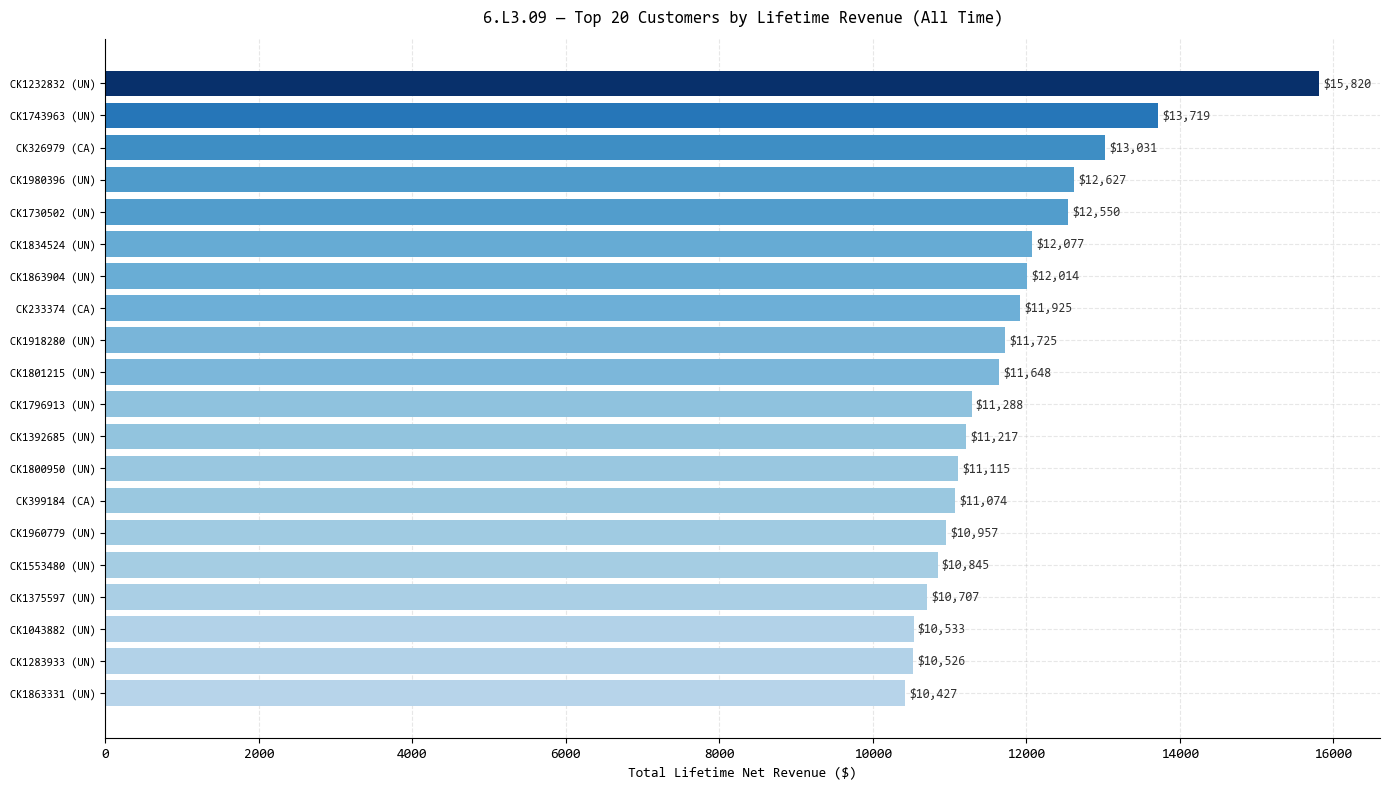

    CustomerKey         Country  OrderCount  LifetimeRevenue
1       1232832   United States           5       15820.0515
2       1743963   United States           6       13718.5989
3        326979          Canada           5       13030.7803
4       1980396   United States           4       12627.1836
5       1730502   United States           2       12549.9260
6       1834524   United States           8       12077.1290
7       1863904   United States           3       12014.4008
8        233374          Canada           5       11925.0596
9       1918280   United States           3       11725.1234
10      1801215   United States           6       11647.6751
11      1796913   United States           6       11287.5015
12      1392685   United States           2       11217.0833
13      1800950   United States           5       11114.7736
14       399184          Canada           3       11074.2804
15      1960779   United States           3       10957.1636
16      1553480   United

In [ ]:
# 6.L3.09 - Top 20 customers by lifetime revenue (reuse df_lifetime)
top_customers = df_lifetime.nlargest(20, 'LifetimeRevenue')[['CustomerKey','Country','OrderCount','LifetimeRevenue']].reset_index(drop=True)
top_customers.index = top_customers.index + 1

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 8))
labels = [f"CK{int(row['CustomerKey'])} ({row['Country'][:2].upper()})" for _, row in top_customers.iterrows()]
vals = top_customers['LifetimeRevenue'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
bars = ax.barh(labels[::-1], vals[::-1], color=colors[::-1])
for bar, v in zip(bars, vals[::-1]):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2, f'${v:,.0f}',
            ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('6.L3.09 — Top 20 Customers by Lifetime Revenue (All Time)', fontsize=12, fontfamily='Consolas', pad=12)
ax.set_xlabel('Total Lifetime Net Revenue ($)', fontsize=10)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()
print(top_customers.to_string())

### Key Insight — 6.L3.09
**The #1 customer (CK1232832, US) has $15,820 in lifetime revenue across 5 orders — nearly 11x the overall average CLV of $1,414. The top 20 customers are almost exclusively from the United States (17/20), with 3 from Canada and 1 from the UK.**
The top 20 customers collectively have lifetime revenues of $10,427–$15,820, compressed into a relatively tight range — there is no single "super customer" an order of magnitude above the rest. Most have 2–8 orders, suggesting that CLV is driven primarily by high-ticket purchases rather than high frequency.
CK1730502 is notable: $12,550 lifetime revenue with only 2 orders — an average ticket of ~$6,275 per order, the highest in the top 20. This customer represents the "occasional big spender" archetype that is most at risk of disappearing silently — a single missed purchase materially impacts lifetime value.

> **Analysis Limitation:** Customer names are not shown for privacy. The top customer list uses `CustomerKey` as the identifier — a CRM lookup would be required to initiate outreach. The "UN" suffix in chart labels abbreviates United States (US), not United Nations.